In [ ]:
import pandas as pd
import numpy as np

#load expert benchmark , N=1,000
dfe

In [12]:
def aggregate_votes(series):
    """
    
    """
    return (
        series
        .fillna("")
        .astype(str)
        .str.split(",")
        .apply(lambda xs: np.mean([int(x.strip()) for x in xs])))


for v in values_list:
    dfe[f"{v}_expert_prob"] = aggregate_votes(dfe[f"{v}_e_raw"])

PR-AUC

In [18]:
import numpy as np
from sklearn.metrics import average_precision_score

def compute_pr_auc_table(df, values_list, col_suff):

    results = []

    for v in values_list:
        
        # --- Targets ---
        expert_binary = (df[f"{v}_expert_prob"] >= 0.6).astype(int)
        llm_binary = (df[f"{v}_llm_prob"] >= 0.6).astype(int)

        # --- Scores ---
        llm_scores = df[f"{v}_llm_prob"]
        bert_scores = df[f"{v}_bert_{col_suff}"]

        # --- PR-AUC ---
        pr_llm_exp = average_precision_score(expert_binary, llm_scores)
        pr_bert_exp = average_precision_score(expert_binary, bert_scores)
        pr_bert_llm = average_precision_score(llm_binary, bert_scores)

        results.append({
            "Value": v,
            "PR-AUC LLM→Expert": pr_llm_exp,
            "PR-AUC BERT→Expert": pr_bert_exp,
            "PR-AUC BERT→LLM": pr_bert_llm
        })

    results_df = pd.DataFrame(results)
    
    # macro averages
    macro_row = {
        "Value": "MACRO_AVG",
        "PR-AUC LLM→Expert": results_df["PR-AUC LLM→Expert"].mean(),
        "PR-AUC BERT→Expert": results_df["PR-AUC BERT→Expert"].mean(),
        "PR-AUC BERT→LLM": results_df["PR-AUC BERT→LLM"].mean()
    }
    
    results_df = pd.concat([results_df, pd.DataFrame([macro_row])], ignore_index=True)

    return results_df

In [20]:
qwe=compute_pr_auc_table(dfe, values_list, "soft_bce")
qwe

,Value,PR-AUC LLM→Expert,PR-AUC BERT→Expert,PR-AUC BERT→LLM
0,Self-direction,0.538944,0.585350,0.739836
1,Stimulation,0.406261,0.439981,0.651481
2,Hedonism,0.585508,0.680836,0.669647
3,Achievement,0.689393,0.732542,0.814416
4,Power,0.392392,0.469244,0.524376
5,Security,0.590622,0.718522,0.721633
6,Conformity,0.262607,0.234552,0.360081
7,Tradition,0.513651,0.667786,0.795655
8,Benevolence,0.917579,0.943831,0.944472
9,Universalism,0.607690,0.557065,0.711715


In [ ]:
#load test data
#df_test

In [48]:
import matplotlib as mpl

def plot_cdf_grid(df, values_list, col_suff):

    import matplotlib.pyplot as plt
    import numpy as np

    plt.rcParams.update({
        "axes.edgecolor": "#888888",
        "axes.linewidth": 0.6,
        "grid.color": "#cccccc",
        "grid.linewidth": 0.6
    })
    mpl.rcParams['font.family'] = 'STIXGeneral'

    fig, axes = plt.subplots(
        5, 2,
        figsize=(7, 11),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    llm_color = "#B03117"
    bert_color = "#2C4C7E"
    exp_color = "#4C9136"

    for i, v in enumerate(values_list):
        ax = axes[i]

        # LLM confidence (votes/5)
        llm_data = df[f"{v}_llm_prob"].dropna().values
        x_llm = np.sort(llm_data)
        y_llm = np.arange(1, len(x_llm) + 1) / len(x_llm)

        # BERT probability
        bert_data = df[f"{v}_bert_{col_suff}"].dropna().values
        x_bert = np.sort(bert_data)
        y_bert = np.arange(1, len(x_bert) + 1) / len(x_bert)

        # Expert aggregated probability (0 / 0.6 / 1)
        expert_data = df[f"{v}_expert_prob"].dropna().values
        x_exp = np.sort(expert_data)
        y_exp = np.arange(1, len(x_exp) + 1) / len(x_exp)

        # LLM — пунктир
        ax.plot(
            x_llm, y_llm,
            linestyle="-",
            linewidth=2,
            color=llm_color,
            alpha=0.9
        )

        # Experts — 
        ax.plot(
            x_exp, y_exp,
            linestyle="--",
            linewidth=2,
            color=exp_color,
            alpha=0.9
        )

        # BERT — сплошная
        ax.plot(
            x_bert, y_bert,
            linewidth=2.0,
            color=bert_color,
            alpha=0.95
        )

        ax.set_title(v, fontsize=18)
        ax.set_yticks([0, 0.5, 1])
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

        # только горизонтальная сетка
        ax.grid(axis="y", alpha=0.3)

        # убираем верхнюю и правую рамку
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


    from matplotlib.lines import Line2D

    legend_elements = [
    Line2D([0], [0], color=exp_color, lw=2, linestyle="--", label="Experts"),
    Line2D([0], [0], color=llm_color, lw=2, label="Gemini"),
    Line2D([0], [0], color=bert_color, lw=2.0, label="XLM-RoBERTa")]

    fig.legend(
        handles=legend_elements,
        # loc="upper center",
        bbox_to_anchor=(0.98, 0.97),
        ncol=3,
        frameon=False,
        fontsize=18
    )
    fig.suptitle(
        " ",
        fontsize=20,
        fontweight="bold",
        y=1
    )
    fig.supxlabel("Probability", fontsize=18)
    fig.supylabel("Cumulative proportion", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    plt.show()

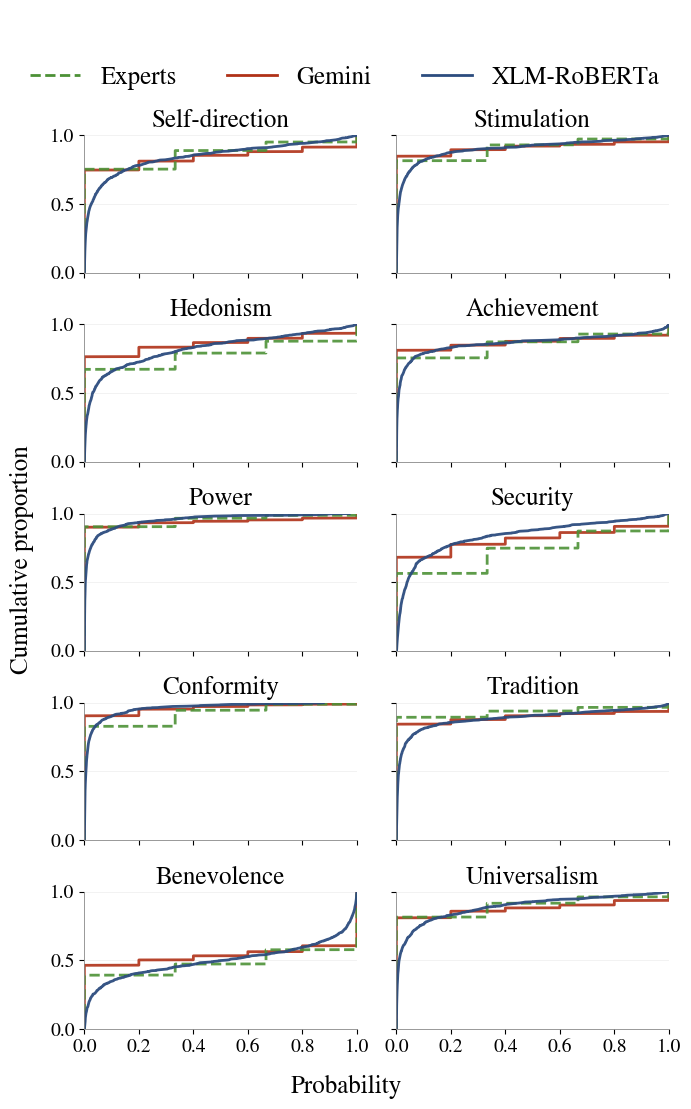

In [49]:
plot_cdf_grid(dfe, values_list, "soft_bce")

In [24]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

def parse_votes(x):
    return [int(float(i.strip())) for i in str(x).split(",")]

def spearman_expert_agreement_vs_probability(df, values_list, prob_suffix):

    rows = []

    for v in values_list:

        # число экспертных голосов
        expert_votes = (
            df[f"{v}_e_raw"]
            .apply(parse_votes)
            .apply(sum)
        )

        # probabilities модели
        probs = df[f"{v}_bert_{prob_suffix}"]

        rho, pval = spearmanr(expert_votes, probs)

        rows.append({
            "value": v,
            "spearman_rho": rho,
            "p_value": pval
        })

    return pd.DataFrame(rows)

In [25]:
corr_df = spearman_expert_agreement_vs_probability(
    df=dfe,
    values_list=values_list,
    prob_suffix="soft_bce"   
)

corr_df.round(3)[["value", "spearman_rho"]]

,value,spearman_rho
0,Self-direction,0.545
1,Stimulation,0.444
2,Hedonism,0.624
3,Achievement,0.600
4,Power,0.368
5,Security,0.597
6,Conformity,0.333
7,Tradition,0.443
8,Benevolence,0.813
9,Universalism,0.532


In [58]:
import numpy as np
import matplotlib.pyplot as plt

for v in values_list:
    df_test[f"{v}_llm_conf"] = df_test[f"{v}"].apply(lambda s: sum(map(int, s.split(","))) / 5)


def plot_cdf_grid_test(df, values, col_suf):

    fig, axes = plt.subplots(5, 2, figsize=(7, 11), sharex=True, sharey=True)
    axes = axes.flatten()


    
    for i, value in enumerate(values):

        ax = axes[i]

        for col, label, color in [
            (f"{value}_llm_conf", "Gemini", "#B03117"),
            (f"{value}_bert_prob", "XLM-RoBERTa", "#2C4C7E")
        ]:

            data = df[col].dropna().values
            x = np.sort(data)
            y = np.arange(1, len(x)+1) / len(x)

            ax.plot(x, y, linewidth=2, label=label, color=color)

        ax.set_title(value, fontsize=18)
        ax.set_xlim(0,1)
        ax.set_ylim(0, 1.02)
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_yticks([0, 0.5, 1])
        
        # только горизонтальная сетка
        ax.grid(axis="y", alpha=0.3)

        # убираем верхнюю и правую рамку
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

    # Убираем лишние подписи
    for ax in axes:
        ax.label_outer()

        # только горизонтальная сетка
        ax.grid(axis="y", alpha=0.3)

        # убираем верхнюю и правую рамку
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        # Общая легенда
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=3, fontsize=18, bbox_to_anchor=(0.85, 0.975), frameon=False,)

    fig.suptitle(
        "  ",
        fontsize=16,
        fontweight="bold",
        y=0.98
    )

    fig.supxlabel("Probability", fontsize=18)
    fig.supylabel("Cumulative proportion", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

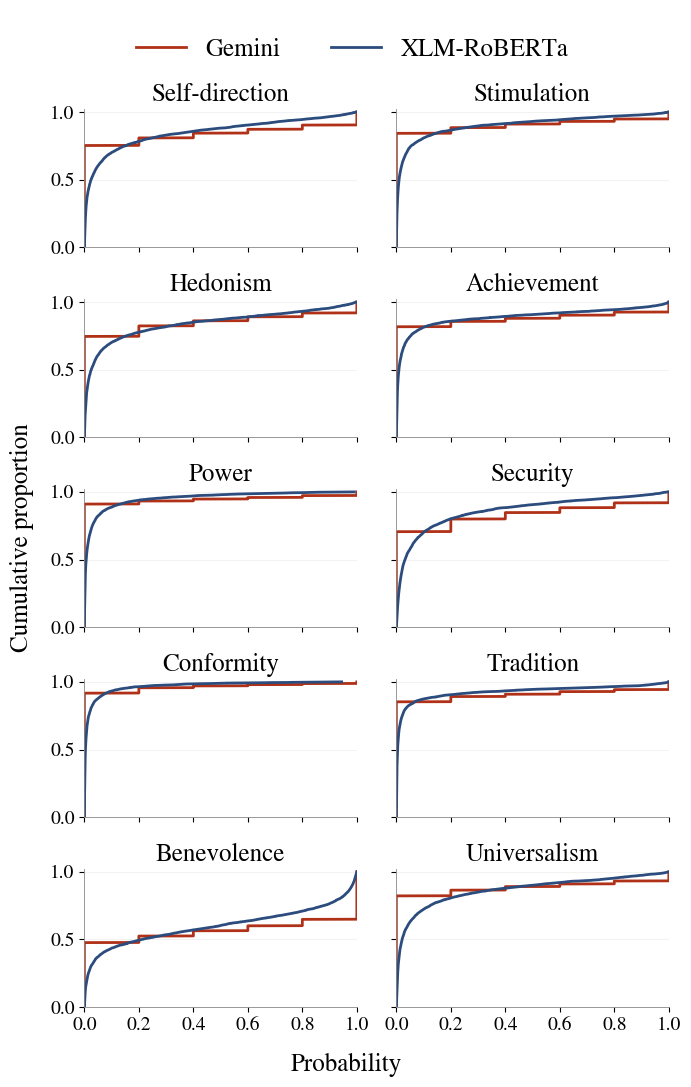

In [59]:
plot_cdf_grid_test(df_test, values_list, "soft_bce")